Here, we compare Logistic Regression, XGBoost, SVC, and RandomForest's performance via nestedCV.

# Imports

In [1]:
import pandas as pd
import numpy as np

# Get and Format Data

In [2]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [3]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/amazon_train_{year}.csv"), year) for year in range(2021, 2024)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

taiga_train_sets = [prepare_data(pd.read_csv(f"datasets/taiga_train_{year}.csv"), year) for year in range(2021, 2024)]
taiga_train = pd.concat(taiga_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/borneo_train_{year}.csv"), year) for year in range(2021, 2024)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

train_set = pd.concat([amazon_train, taiga_train, borneo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year').reset_index()
print(train_set.head())
print(train_set.groupby('year')['class'].count())

   index system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
0     17     1_1017_0        0.023751  0.236899         0.024790   0.144549   
1    614     1_1614_0        0.068061  0.293373         0.055900   0.148055   
2    246     1_1248_0        0.030325  0.388929         0.028639   0.237550   
3   1053       2_54_0       -0.007150  0.339695        -0.005900   0.205870   
4   1693      2_737_0       -0.155823  0.246071        -0.075521   0.186623   

   NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  ...  SR_B5_lag1  \
0         0.033430   0.310114            -401.0      8141.0  ...     13972.0   
1         0.042778   0.361622             -56.5      8601.5  ...     17816.5   
2         0.035078   0.447652            -482.0      8420.0  ...     22303.0   
3        -0.010492   0.381207             -58.0      7988.0  ...     17550.5   
4        -0.146124   0.308125             -74.0      8051.0  ...     19281.5   

   SR_B6_delta_lag1  SR_B6_lag1  SR_B7_delta

In [4]:
print(len(amazon_train))
print(len(taiga_train))
print(len(borneo_train))

5969
6000
5848


# Feature Selection

In [5]:
all_features = train_set.columns.drop(['year', 'index', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])
print(all_features)

Index(['NBR_delta_lag4', 'NBR_lag4', 'NDMI_delta_lag4', 'NDMI_lag4',
       'NDVI_delta_lag4', 'NDVI_lag4', 'SR_B4_delta_lag4', 'SR_B4_lag4',
       'SR_B5_delta_lag4', 'SR_B5_lag4', 'SR_B6_delta_lag4', 'SR_B6_lag4',
       'SR_B7_delta_lag4', 'SR_B7_lag4', 'NBR_delta_lag3', 'NBR_lag3',
       'NDMI_delta_lag3', 'NDMI_lag3', 'NDVI_delta_lag3', 'NDVI_lag3',
       'SR_B4_delta_lag3', 'SR_B4_lag3', 'SR_B5_delta_lag3', 'SR_B5_lag3',
       'SR_B6_delta_lag3', 'SR_B6_lag3', 'SR_B7_delta_lag3', 'SR_B7_lag3',
       'NBR_delta_lag2', 'NBR_lag2', 'NDMI_delta_lag2', 'NDMI_lag2',
       'NDVI_delta_lag2', 'NDVI_lag2', 'SR_B4_delta_lag2', 'SR_B4_lag2',
       'SR_B5_delta_lag2', 'SR_B5_lag2', 'SR_B6_delta_lag2', 'SR_B6_lag2',
       'SR_B7_delta_lag2', 'SR_B7_lag2', 'NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag

In [6]:
X_train = train_set[all_features]
y_train = train_set['class']

class               1.000000
NBR_delta_lag3      0.544072
SR_B7_delta_lag3    0.543627
SR_B7_delta_lag4    0.542301
SR_B7_delta_lag2    0.535465
NBR_delta_lag4      0.533444
NBR_delta_lag2      0.533070
SR_B7_delta_lag1    0.509305
NDMI_delta_lag3     0.498901
NDMI_delta_lag4     0.493961
NBR_delta_lag1      0.493442
NDMI_delta_lag2     0.486412
NDVI_delta_lag3     0.446424
NDMI_delta_lag1     0.443067
SR_B6_delta_lag4    0.441876
SR_B6_delta_lag3    0.439632
NDVI_delta_lag2     0.438087
NDVI_delta_lag4     0.435486
SR_B6_delta_lag2    0.430869
SR_B6_delta_lag1    0.413092
NDVI_delta_lag1     0.408822
SR_B5_delta_lag3    0.222721
SR_B5_delta_lag2    0.209143
SR_B5_delta_lag4    0.205878
SR_B4_delta_lag3    0.202897
SR_B4_delta_lag2    0.199912
SR_B4_delta_lag1    0.197277
SR_B4_delta_lag4    0.189832
NDMI_lag1           0.172276
SR_B5_delta_lag1    0.171142
SR_B7_lag1          0.156176
SR_B6_lag1          0.151665
SR_B6_lag3          0.130178
SR_B6_lag2          0.129420
SR_B6_lag4    

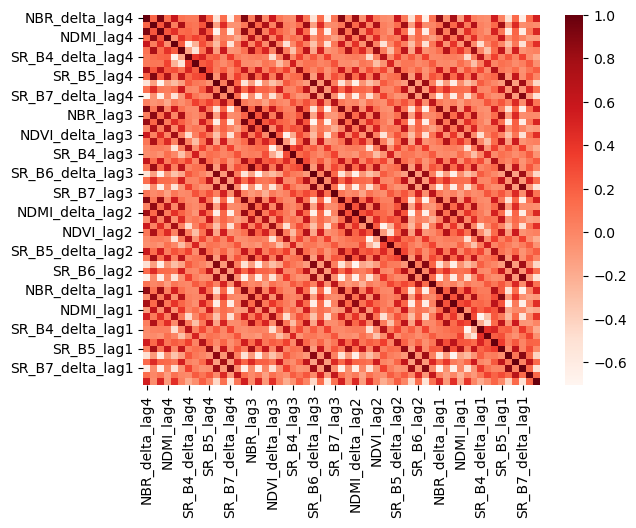

In [7]:
import seaborn as sns
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), cmap='Reds')
print(abs(pd.concat([X_train, y_train], axis=1).corr()['class']).sort_values(ascending=False))

As expected, Landsat deltas are highly correlated with deforestation.

# Compare Models

In [8]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_validate


## Logistic Regression

In [10]:

cv_iterator = custom_year_ts_split(train_set, 'year')
logistic_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', LogisticRegressionCV(
        cv=5, 
        l1_ratios=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 
        max_iter=5000,
        solver='saga',
        random_state=1,
        use_legacy_attributes=False))])
logistic_results = cross_validate(
    logistic_pipe, 
    X_train, 
    y_train, 
    cv=cv_iterator, 
    return_estimator=True,
    scoring=['f1', 'precision', 'recall'], 
    return_train_score=True  # Crucial for detecting overfitting
)

KeyboardInterrupt: 

In [ ]:
print(f"Mean Test f1: {logistic_results['test_f1'].mean():.4f}")
print(f"Mean Test Precision: {logistic_results['test_precision'].mean():.4f}")
print(f"Mean Test Recall: {logistic_results['test_recall'].mean():.4f}")

print(f"Mean Train f1: {logistic_results['train_f1'].mean():.4f}")
print(f"Mean Train Precision: {logistic_results['train_precision'].mean():.4f}")
print(f"Mean Train Recall: {logistic_results['train_recall'].mean():.4f}")

print(f"Overfitting Ratio: {1-logistic_results['test_f1'].mean()/logistic_results['train_f1'].mean()}")

Mean Test f1: 0.8327
Mean Test Precision: 0.9077
Mean Test Recall: 0.7691
Mean Train f1: 0.8480
Mean Train Precision: 0.8896
Mean Train Recall: 0.8102
Overfitting Ratio: 0.018104202430709537


Logistic Regression exhibits strong f1 scores and no overfitting.

## XGBoost

In [11]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [12]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [13]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [14]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 0.8638227440034687, 'model__colsample_bynode': 0.5189939741408653, 'model__max_depth': 3, 'model__min_child_weight': 2, 'model__reg_alpha': 2.8993206494926964, 'model__reg_lambda': 7.052720465451715, 'model__subsample': 0.7428073783474053})
Outer Fold 1 - Inner Mean Test Score:  0.876461
Outer Fold 1 - Inner Test Score STD:  0.004985
Outer Fold 1 - Inner Mean Train Score: 0.934459
Outer Fold 1 - Inner Train Score STD:  0.004985
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 0.5167591538097573, 'model__colsample_bynode': 0.64720632558579, 'model__max_depth': 5, 'model__min_child_weight': 43, 'model__reg_alpha': 9.861004658321784, 'model__reg_lambda': 0.23322791174338223, 'model__subsample': 0.9997950940107446})
Outer Fold 2 - Inner Mean Test Score:  0.880723
Outer Fold 2 - Inner Test Score STD:  0.007740
Outer Fold 2 - Inner Mean Train Score: 0.920964
Outer Fold 2 - Inner Train Score STD:  0.007740

O

XGBoost outperforms Logistic Regression and SVC, but has more risk of overfitting.

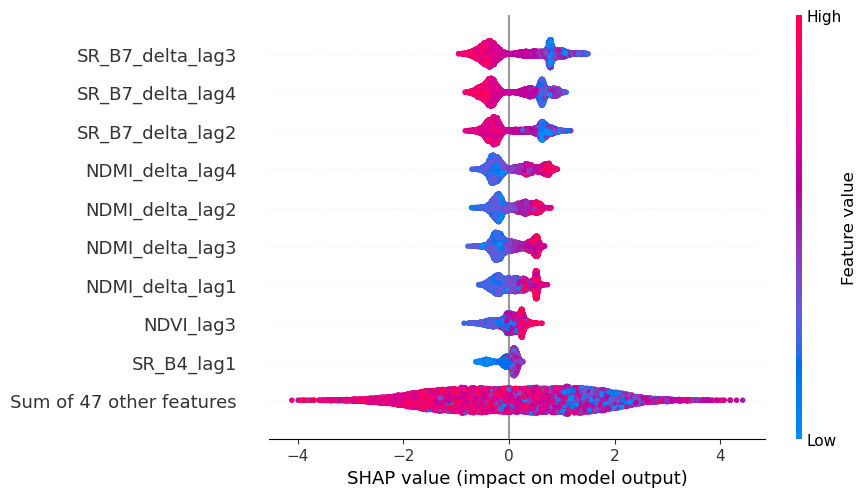

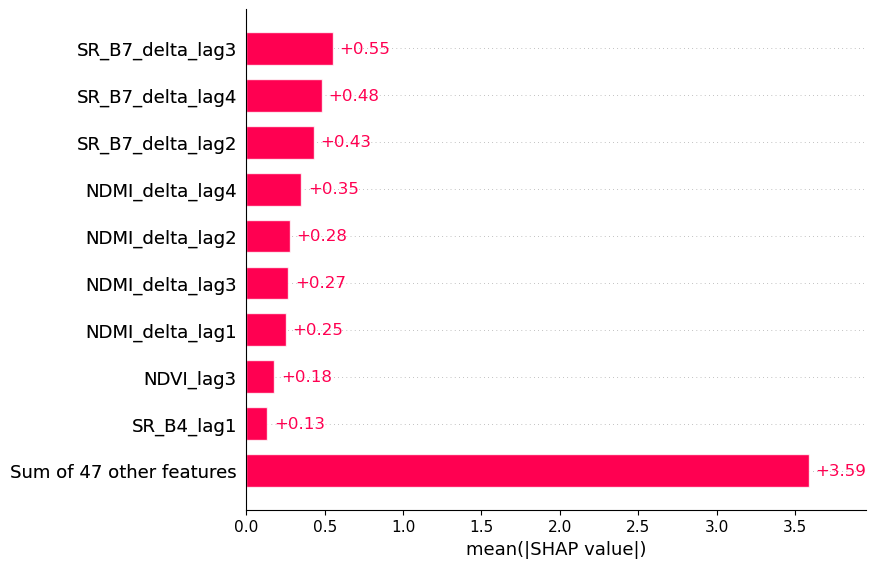

In [15]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X_train, y_train)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X_train),
    columns=all_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


## SVC

In [16]:
from sklearn.svm import SVC

In [17]:
svc_param_grid = {
    'model__C': Real(0.1, 10),
    'model__kernel': Categorical(['linear', 'poly', 'rbf'])
}

In [18]:
svc_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', SVC(random_state=1))])

tuner = BayesSearchCV(
    estimator=svc_pipe,
    cv=5,
    n_iter=32,
    search_spaces=svc_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

cv_iterator = custom_year_ts_split(train_set, 'year')

svc_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [19]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(svc_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {svc_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {svc_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {svc_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {svc_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {svc_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {svc_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-svc_results['test_f1'].mean()/svc_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__C': 4.395814809588213, 'model__kernel': 'rbf'})
Outer Fold 1 - Inner Mean Test Score:  0.870228
Outer Fold 1 - Inner Test Score STD:  0.009901
Outer Fold 1 - Inner Mean Train Score: 0.906542
Outer Fold 1 - Inner Train Score STD:  0.009901
Outer Fold 2 Parameters - OrderedDict({'model__C': 4.497318891833025, 'model__kernel': 'rbf'})
Outer Fold 2 - Inner Mean Test Score:  0.875134
Outer Fold 2 - Inner Test Score STD:  0.008676
Outer Fold 2 - Inner Mean Train Score: 0.900523
Outer Fold 2 - Inner Train Score STD:  0.008676

Overall Metrics
Mean Test f1: 0.85742828
Mean Test Precision: 0.92889727
Mean Test Recall: 0.79617206
Mean Train f1: 0.90195338
Mean Train Precision: 0.94334848
Mean Train Recall: 0.86403975
Overfitting Ratio: 0.04936518713113136


SVC beats Logistic Regression, but loses to XGBoost and Random Forest. However, it has less overfitting.

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
rf_param_grid = {
    'max_depth': Integer(2, 12),
    'min_samples_split': Integer(2, 40),
    'min_samples_leaf': Integer(2, 40),
    'max_features': Real(0.1, 1),
}

In [22]:
rf_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', BayesSearchCV(
        estimator=RandomForestClassifier(random_state=1),
        cv=5, 
        refit='f1',
        search_spaces=rf_param_grid,
        return_train_score=True,
        random_state=1,
        scoring='f1'
    ))])

cv_iterator = custom_year_ts_split(train_set, 'year')

rf_results = cross_validate(
    rf_pipe,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

KeyboardInterrupt: 

In [ ]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(rf_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_train:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {rf_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {rf_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {rf_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {rf_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {rf_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {rf_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-rf_results['test_f1'].mean()/rf_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'max_depth': 12, 'max_features': 0.10000000000000003, 'min_samples_leaf': 2, 'min_samples_split': 2})
Outer Fold 1 - Inner Mean Test Score:  0.874458
Outer Fold 1 - Inner Test Score STD:  0.012811
Outer Fold 1 - Inner Mean Train Score: 0.975287
Outer Fold 1 - Inner Train Score STD:  0.000985
Outer Fold 2 Parameters - OrderedDict({'max_depth': 12, 'max_features': 0.7792407740706278, 'min_samples_leaf': 2, 'min_samples_split': 2})
Outer Fold 2 - Inner Mean Test Score:  0.875040
Outer Fold 2 - Inner Test Score STD:  0.005537
Outer Fold 2 - Inner Mean Train Score: 0.975316
Outer Fold 2 - Inner Train Score STD:  0.000943

Overall Metrics
Mean Test f1: 0.86886917
Mean Test Precision: 0.91575854
Mean Test Recall: 0.82656280
Mean Train f1: 0.97273056
Mean Train Precision: 0.98918088
Mean Train Recall: 0.95683198
Overfitting Ratio: 0.10677302683974677


Random Forest performs similarly to XGBoost.

# Observations
* All models do well. Yay! 
    * The Landsat bands are useful in predicting deforestation. 
    * The high correlation between the targets and the delta bands confirms the predictive quality of those engineered features.
* Precision > Recall. All the models can effectively catch deforestation, but do worse at identifying pixels with no deforestation.
* Best Model: XGBoost. XGBoost did significantly better than logistic regression, and did not significantly overfit.